# Pairs plot

The scores plot draws one pair of components. The pairs plot draws them all: a square grid crossing every component against every other, with the scatter off the diagonal and a histogram of each component along it.

    plot_pairs(scores; comps = [...], group = ..., compnames = ..., kwargs...)

That is the view the scores plot cannot give. A class that separates on no single pair but does on some third one shows up here immediately, and we do not have to guess which pair to look at first.

The grid is square in the number of components crossed, so it grows fast — four make sixteen cells, six make thirty six. Three or four is usually as much as reads, and `comps` is there to say which.

## Setup

In [1]:
using BigRiverEssence
using WolfRiverPlots
using Plots
using StableRNGs

## A simulated example

The same data as the other notebooks. We fit eight components deliberately, even though only three signals are at work — that way the grid shows us both the components carrying structure and the ones fitting noise, which is exactly the comparison the plot is for.

In [2]:
rng = StableRNG(20240801)

n = 90    # observations
p = 20    # variables

latent = randn(rng, n, 3)
X = latent * randn(rng, 3, p) .+ 0.3 .* randn(rng, n, p)

# the class is read off the first latent signal
y = [latent[i, 1] > 0.4 ? "a" : latent[i, 1] < -0.4 ? "c" : "b" for i in 1:n]

m = pca(X; k = 8)
S = pca_transform(m, X)

size(S)   # observations by components

(90, 8)

## The default plot

With no `comps` every component is crossed, which here means an eight by eight grid — sixty four cells, far more than reads at the default canvas size. We keep it short instead and cross the first three.

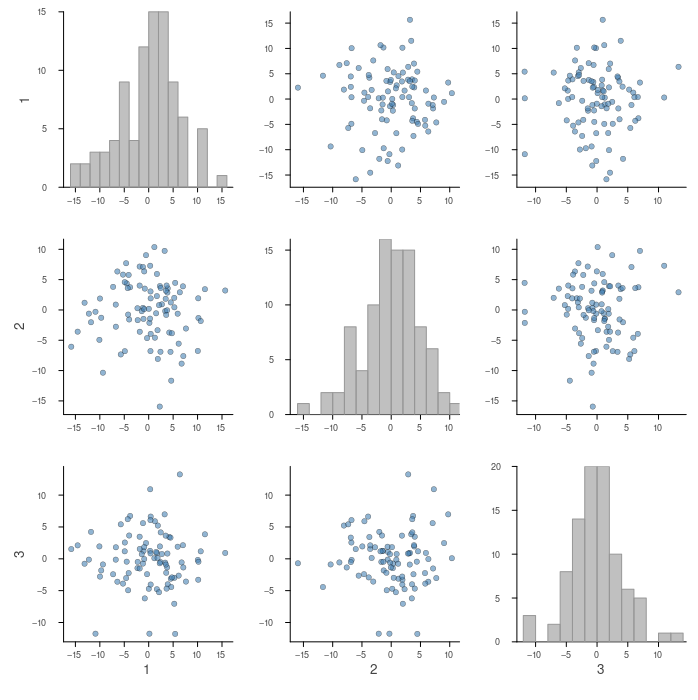

In [3]:
plot_pairs(S; comps = [1, 2, 3])

---

# Modifying the plot

`comps` chooses which components are crossed and `group` colors the points by class. `compnames` names them — and here is the convention worth internalising, since it is the usual way this call fails:

**`compnames` is one name per component of the matrix, not one per entry of `comps`.** Our matrix has eight components, so we pass eight names even when crossing three. The helper subsets them itself, so it needs the full list to index into. Writing `["PC $(j)" for j in 1:size(S, 2)]` tracks whatever we fitted with and avoids the mismatch entirely.

The other quirk: each cell is titled by the plot, so a `title` we pass would repeat once per cell and is blanked. The grid takes **`plot_title`** instead.

## Grouping and naming

With `group` the points are colored by class and one legend is written for the whole grid rather than one per cell. Each class keeps its color across every cell, so a cluster can be followed from one pair to the next.

Note what the grid tells us that a single pair could not: the classes separate cleanly on the first component, and the cells crossing it with anything else all show that same split, while the cells among the later components show none.

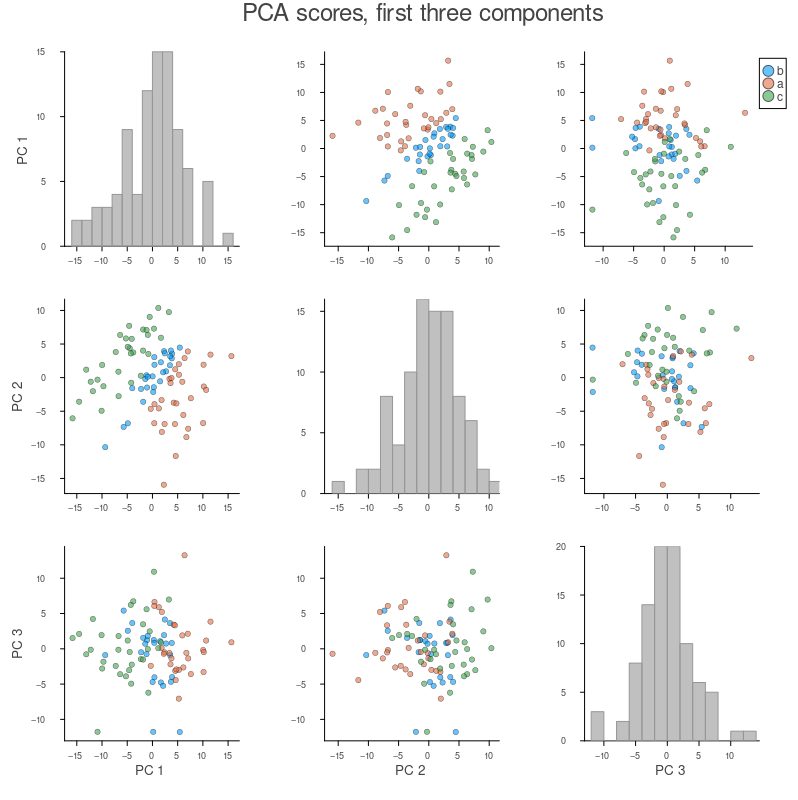

In [4]:
plot_pairs(S;
           comps      = [1, 2, 3],
           group      = y,
           compnames  = ["PC $(j)" for j in 1:size(S, 2)],
           plot_title = "PCA scores, first three components",
           size       = (800, 800))

## A non-contiguous subset

`comps` need not be consecutive. Crossing components 1, 3 and 5 is often the more useful question — whether a later component carries anything the earlier ones missed — and the diagonal histograms make the answer plain: a component fitting noise has a single unstructured mound, while one carrying signal shows the classes pulled apart.

We also bump the canvas, since the grid needs room.

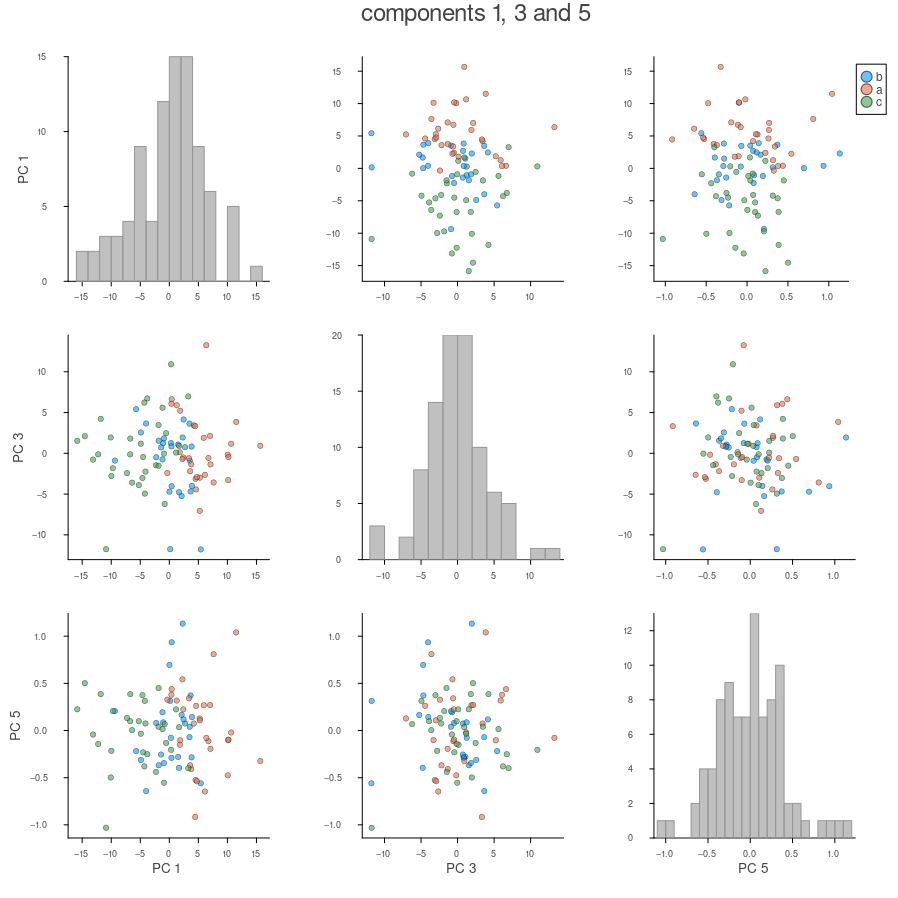

In [5]:
plot_pairs(S;
           comps      = [1, 3, 5],
           group      = y,
           compnames  = ["PC $(j)" for j in 1:size(S, 2)],
           plot_title = "components 1, 3 and 5",
           size       = (900, 900))

## The diagonal, and the rest

Two knobs of our own act on the diagonal: `diagcolor` sets the histogram color and `diagbins` the number of bins. The diagonal shares its x limits with its column so the histogram lines up with the scatter above and below it, but its y axis is a count and is left alone.

Everything else the plot sets for itself yields to what we pass — marker size, canvas, fonts. Below we also pass a `title`, which is blanked, to show that `plot_title` is the one that carries.

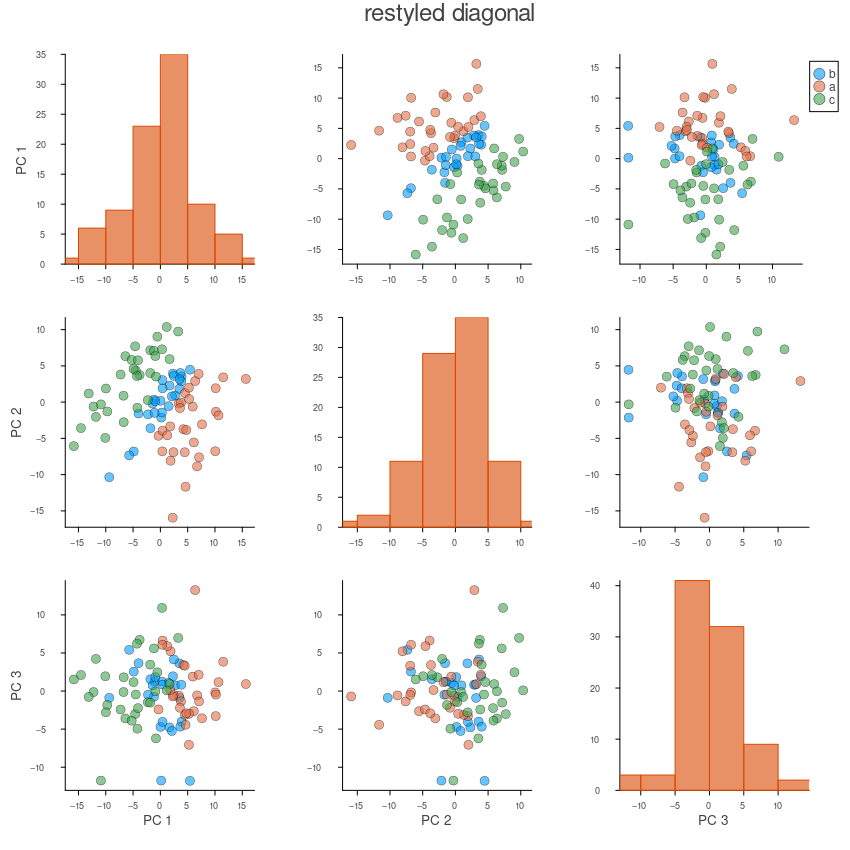

In [6]:
plot_pairs(S;
           comps      = [1, 2, 3],
           group      = y,
           compnames  = ["PC $(j)" for j in 1:size(S, 2)],
           diagcolor  = "#d94801",
           diagbins   = 8,
           markersize = 5,
           title      = "this will not appear",
           plot_title = "restyled diagonal",
           size       = (850, 850))